In [0]:
from pyspark.sql.functions import col
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


In [0]:
from pyspark.sql.functions import sum
revenue_by_city=df.filter(col("status")=="Completed").groupBy("city").agg(sum(col("consultation_fee")))
revenue_by_city.show()

+---------+---------------------+
|     city|sum(consultation_fee)|
+---------+---------------------+
|Hyderabad|                 5600|
|Bangalore|                 6400|
|    Delhi|                 8000|
|  Chennai|                 2400|
+---------+---------------------+



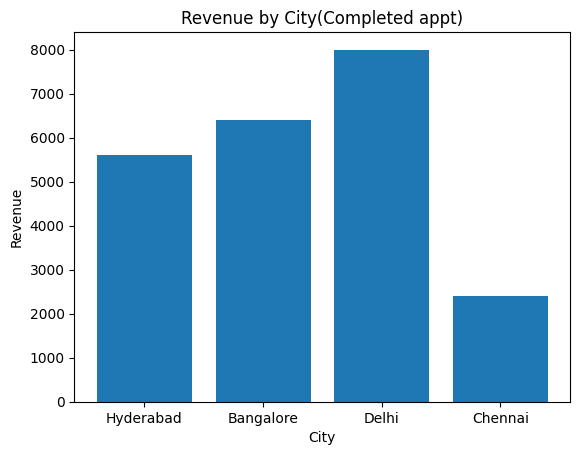

In [0]:
import matplotlib.pyplot as plt
revenue_by_city_pd=revenue_by_city.toPandas()
plt.bar(revenue_by_city_pd["city"],revenue_by_city_pd["sum(consultation_fee)"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City(Completed appt)")
plt.show()

+-----------+---------------------+
| department|sum(consultation_fee)|
+-----------+---------------------+
| Cardiology|                10500|
|  Neurology|                 4900|
|Orthopedics|                 4900|
|Dermatology|                 1000|
| Pediatrics|                 1100|
+-----------+---------------------+



<function matplotlib.pyplot.show(close=None, block=None)>

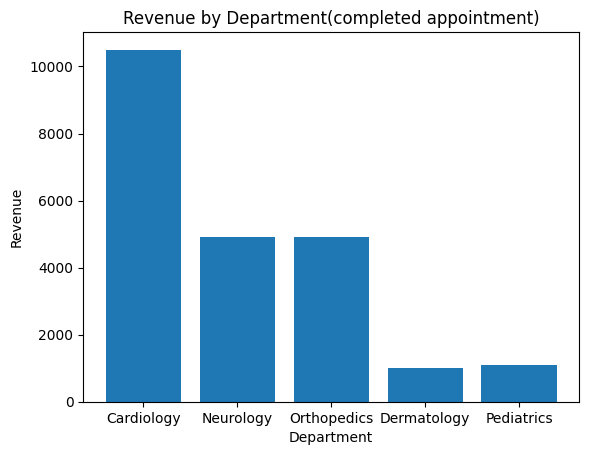

In [0]:
revenue_by_department=df.filter(col("status")=="Completed").groupBy("department").agg(sum(col("consultation_fee")))
revenue_by_department.show()
revenue_by_department_pd=revenue_by_department.toPandas()
plt.bar(revenue_by_department_pd["department"],revenue_by_department_pd["sum(consultation_fee)"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Revenue by Department(completed appointment)")
plt.show()

+---------+-----+
|   status|count|
+---------+-----+
|Completed|   10|
|  Pending|    3|
|Cancelled|    2|
+---------+-----+



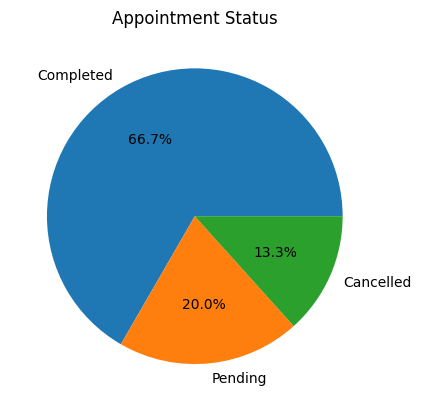

In [0]:
status_df=df.groupBy("status").count()
status_df.show()
plt.pie(status_df.toPandas()["count"],labels=status_df.toPandas()["status"],autopct='%1.1f%%')
plt.title("Appointment Status")
plt.show()


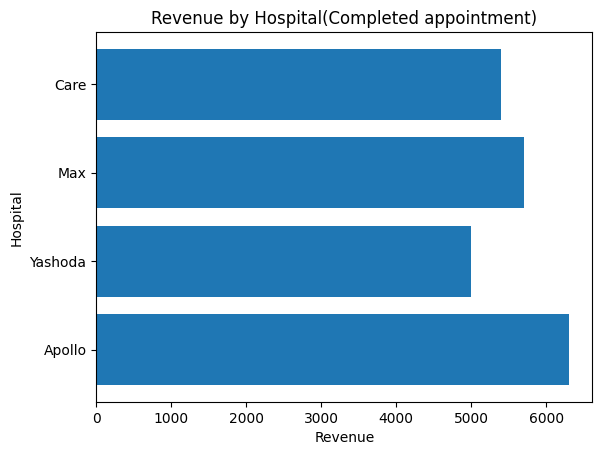

In [0]:
revenue_by_hospital=df.filter(col("status")=="Completed").groupBy("hospital").agg(sum(col("consultation_fee")))
plt.barh(revenue_by_hospital.toPandas()["hospital"],revenue_by_hospital.toPandas()["sum(consultation_fee)"])
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.title("Revenue by Hospital(Completed appointment)")
plt.show()

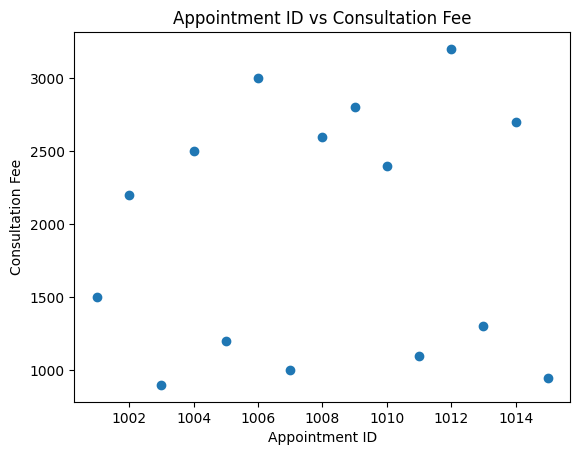

In [0]:
scatter_pd=df.select("appointment_id","consultation_fee").toPandas()
plt.scatter(scatter_pd["appointment_id"],scatter_pd["consultation_fee"])
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")
plt.show()

Text(0.5, 1.0, 'Appointment ID vs Consultation Fee')

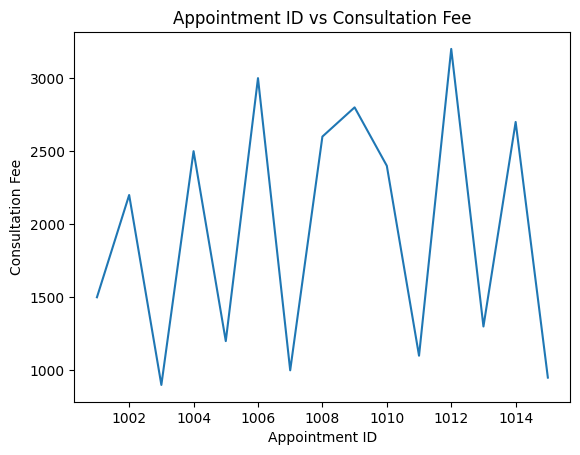

In [0]:
plt.plot(df.select("appointment_id").toPandas()["appointment_id"],df.select("consultation_fee").toPandas()["consultation_fee"])
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")

+---------+---------------------+
|     city|count(appointment_id)|
+---------+---------------------+
|Hyderabad|                    3|
|Bangalore|                    3|
|   Mumbai|                    3|
|    Delhi|                    3|
|  Chennai|                    3|
+---------+---------------------+



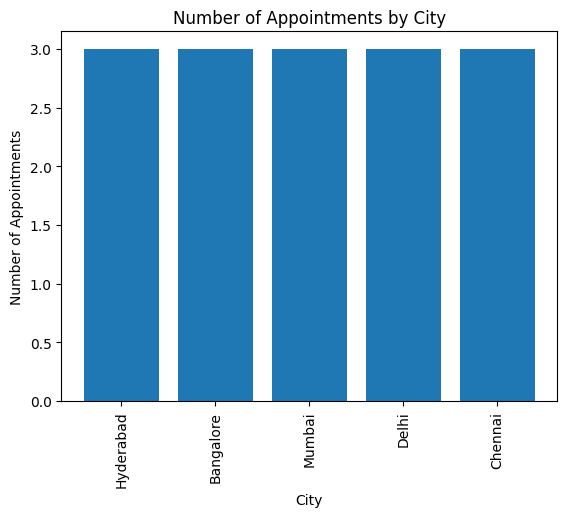

In [0]:
from pyspark.sql.functions import count
appointment_city=df.groupBy("city").agg(count("appointment_id"))
appointment_city.show()
appointment_df=appointment_city.toPandas()
plt.bar(appointment_df["city"],appointment_df["count(appointment_id)"])
plt.xlabel("City")
plt.ylabel("Number of Appointments")
plt.title("Number of Appointments by City")
plt.xticks(rotation=90)
plt.show()

+-----------+---------------------+
| department|count(appointment_id)|
+-----------+---------------------+
| Cardiology|                    4|
|  Neurology|                    3|
|Dermatology|                    3|
|Orthopedics|                    2|
| Pediatrics|                    3|
+-----------+---------------------+



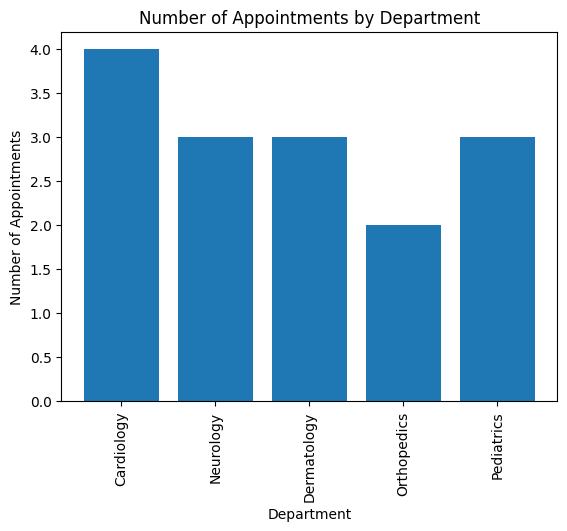

In [0]:
appointment_department=df.groupBy("department").agg(count("appointment_id"))
appointment_department.show()
appointment_department_pd=appointment_department.toPandas()
plt.bar(appointment_department_pd["department"],appointment_department_pd["count(appointment_id)"])
plt.xlabel("Department")
plt.ylabel("Number of Appointments")
plt.title("Number of Appointments by Department")
plt.xticks(rotation=90)
plt.show()

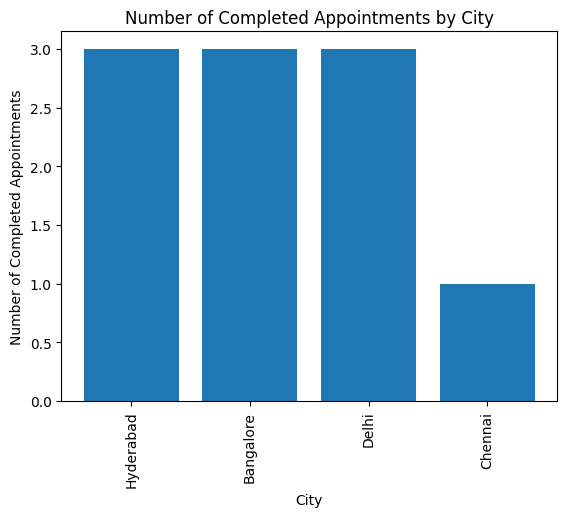

In [0]:
completed_appointment_df=df.filter(col("status")=="Completed").groupBy("city").agg(count("appointment_id")).toPandas()
plt.bar(completed_appointment_df["city"],completed_appointment_df["count(appointment_id)"])
plt.xlabel("City")
plt.ylabel("Number of Completed Appointments")
plt.title("Number of Completed Appointments by City")
plt.xticks(rotation=90)
plt.show()


department,count(appointment_id)
Cardiology,4
Neurology,2
Orthopedics,2
Dermatology,1
Pediatrics,1


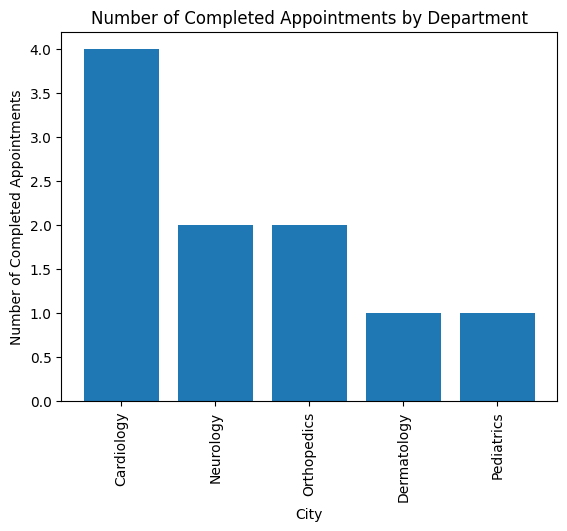

In [0]:
completed_appointment_df_dept=df.filter(col("status")=="Completed").groupBy("department").agg(count("appointment_id")).toPandas()
display(completed_appointment_df_dept)
plt.bar(completed_appointment_df_dept["department"],completed_appointment_df_dept["count(appointment_id)"])
plt.xlabel("City")
plt.ylabel("Number of Completed Appointments")
plt.title("Number of Completed Appointments by Department")
plt.xticks(rotation=90)
plt.show()


+---------+---------------------+
|     city|sum(consultation_fee)|
+---------+---------------------+
|Hyderabad|                 5600|
|Bangalore|                 6400|
|   Mumbai|                 3500|
|    Delhi|                 8000|
|  Chennai|                 3350|
+---------+---------------------+



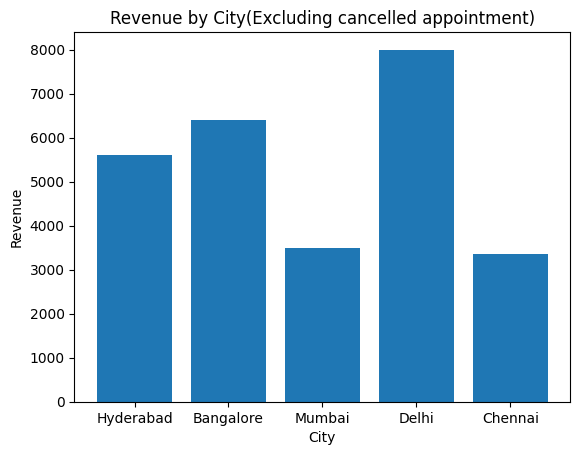

In [0]:
revenue_chart_city=df.filter(col("status")!="Cancelled").groupBy("city").agg(sum(col("consultation_fee")))
revenue_chart_city.show()
revenue_chart_city_pd=revenue_chart_city.toPandas()
plt.bar(revenue_chart_city_pd["city"],revenue_chart_city_pd["sum(consultation_fee)"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City(Excluding cancelled appointment)")
plt.show()

+-----------+---------------------+
| department|sum(consultation_fee)|
+-----------+---------------------+
| Cardiology|                10500|
|  Neurology|                 7500|
|Dermatology|                 2850|
|Orthopedics|                 4900|
| Pediatrics|                 1100|
+-----------+---------------------+



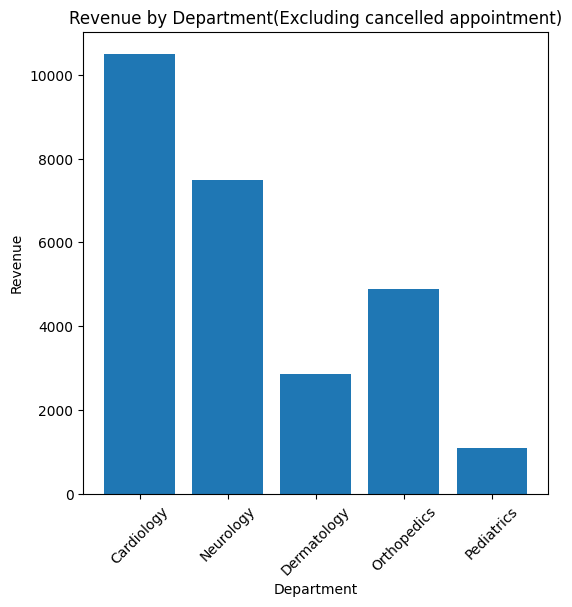

In [0]:
revenue_chart_department=df.filter(col("status")!="Cancelled").groupBy("department").agg(sum(col("consultation_fee")))
revenue_chart_department.show()
revenue_chart_dept_pd=revenue_chart_department.toPandas()
plt.figure(figsize=(6,6))
plt.bar(revenue_chart_dept_pd["department"],revenue_chart_dept_pd["sum(consultation_fee)"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.title("Revenue by Department(Excluding cancelled appointment)")
plt.show()

In [0]:
revenue_by_city.orderBy(col("sum(consultation_fee)").desc())
revenue_by_city.show(3)

+---------+---------------------+
|     city|sum(consultation_fee)|
+---------+---------------------+
|Hyderabad|                 5600|
|Bangalore|                 6400|
|    Delhi|                 8000|
+---------+---------------------+
only showing top 3 rows


In [0]:
revenue_by_department.orderBy(col("sum(consultation_fee)").desc())
revenue_by_department.show(3)


+-----------+---------------------+
| department|sum(consultation_fee)|
+-----------+---------------------+
| Cardiology|                10500|
|  Neurology|                 4900|
|Orthopedics|                 4900|
+-----------+---------------------+
only showing top 3 rows


In [0]:
revenue_by_hospital.orderBy(col("sum(consultation_fee)").asc()).show(1)


+--------+---------------------+
|hospital|sum(consultation_fee)|
+--------+---------------------+
| Yashoda|                 5000|
+--------+---------------------+
only showing top 1 row


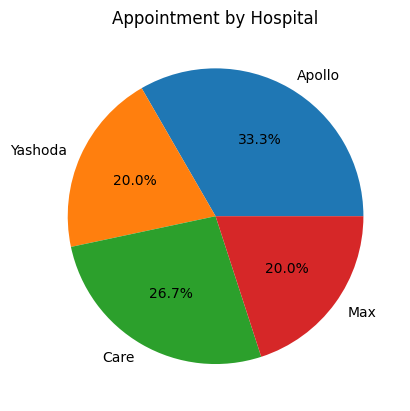

In [0]:
appointment_hospital=df.groupBy("hospital").agg(count("appointment_id"))
appointment_hospital_df=appointment_hospital.toPandas()
plt.pie(appointment_hospital_df["count(appointment_id)"],labels=appointment_hospital_df["hospital"],autopct='%1.1f%%')
plt.title("Appointment by Hospital")
plt.show()

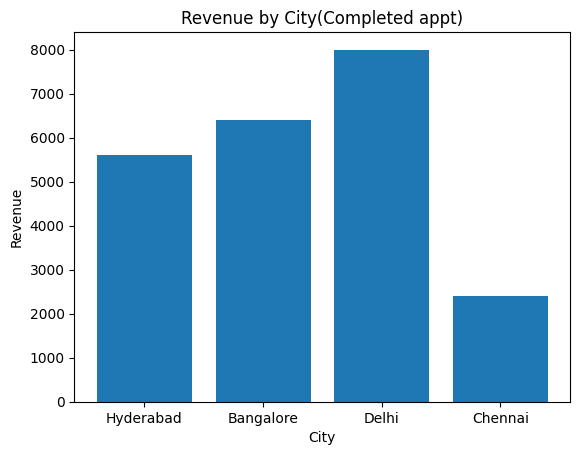

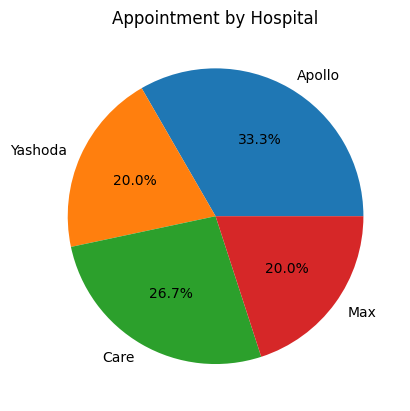

+-----------+---------------------+
| department|sum(consultation_fee)|
+-----------+---------------------+
| Cardiology|                10500|
|  Neurology|                 7500|
|Dermatology|                 2850|
|Orthopedics|                 4900|
| Pediatrics|                 1100|
+-----------+---------------------+



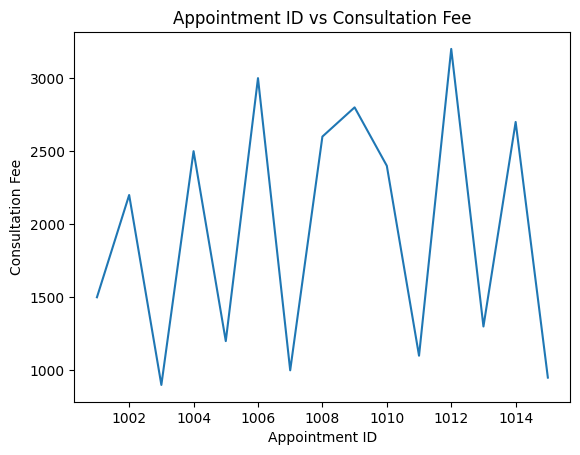

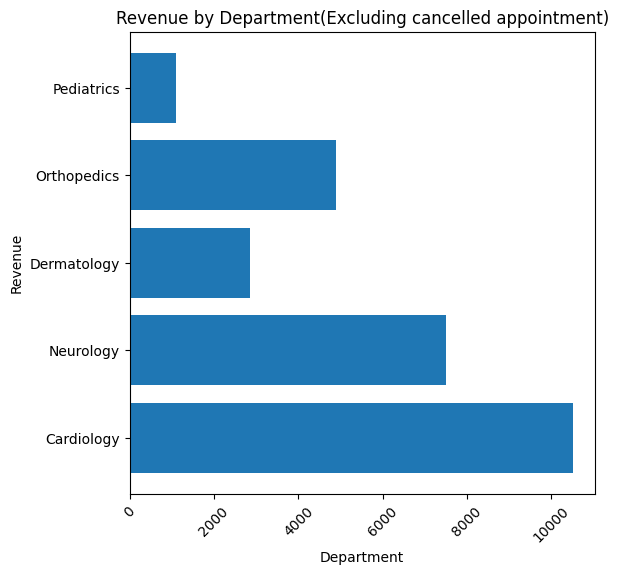

In [0]:
revenue_by_city_pd=revenue_by_city.toPandas()
plt.bar(revenue_by_city_pd["city"],revenue_by_city_pd["sum(consultation_fee)"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City(Completed appt)")
plt.show()
appointment_hospital=df.groupBy("hospital").agg(count("appointment_id"))
appointment_hospital_df=appointment_hospital.toPandas()
plt.pie(appointment_hospital_df["count(appointment_id)"],labels=appointment_hospital_df["hospital"],autopct='%1.1f%%')
plt.title("Appointment by Hospital")
plt.show()
plt.plot(df.select("appointment_id").toPandas()["appointment_id"],df.select("consultation_fee").toPandas()["consultation_fee"])
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")
revenue_chart_department=df.filter(col("status")!="Cancelled").groupBy("department").agg(sum(col("consultation_fee")))
revenue_chart_department.show()
revenue_chart_dept_pd=revenue_chart_department.toPandas()
plt.figure(figsize=(6,6))
plt.barh(revenue_chart_dept_pd["department"],revenue_chart_dept_pd["sum(consultation_fee)"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.title("Revenue by Department(Excluding cancelled appointment)")
plt.show()